In [143]:
!pip install holidays

In [144]:
import pandas as pd
import numpy as np
import holidays
import os

import matplotlib.pyplot as plt
import seaborn as sns

# Load and merge electricity and weather dataset

--- 

in this final project we only choose 1 region for its simplicity, so we can focus more on ML principal principals rather than dataset size problem.

CAL (California) regiom is chosen because it least problematic region:
1. small number of balancing authorities
2. small number/percentage of missing values

In [145]:
selected_region = 'CAL'

In [146]:
weather_df = pd.read_csv(f'weatherEDA_outputs/by_region/open_meteo_{selected_region}_2015-07-01_2026-05-06.csv')
weather_df.head()

,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,timestamp_utc,Region,region_name,weather_city,weather_state,latitude,longitude
0,31.4,31,1.8,0.0,2015-07-01 00:00:00+00:00,CAL,California,Los Angeles,California,34.0522,-118.2437
1,29.9,35,12.7,0.0,2015-07-01 01:00:00+00:00,CAL,California,Los Angeles,California,34.0522,-118.2437
2,28.3,39,8.6,0.0,2015-07-01 02:00:00+00:00,CAL,California,Los Angeles,California,34.0522,-118.2437
3,27.9,39,1.8,0.0,2015-07-01 03:00:00+00:00,CAL,California,Los Angeles,California,34.0522,-118.2437
4,27.3,41,2.2,0.0,2015-07-01 04:00:00+00:00,CAL,California,Los Angeles,California,34.0522,-118.2437


In [147]:
electricity_df = pd.read_csv('electricityEDA_outputs/reproducibility/region_hourly_after_causal_imputation.csv')
electricity_df = electricity_df[electricity_df['Region'] == selected_region]
electricity_df.head()

,timestamp_utc,Region,data_date,region_demand_mw,region_demand_forecast_mw,num_ba,num_rows,num_available_ba,num_missing_ba,year,month,hour,day_of_week,is_negative_demand,target_region_demand_mw,is_target_imputed,imputation_method
0,2015-07-01 08:00:00+00:00,CAL,2015-07-01,38210.0,35264.0,5,5,5,0,2015,7,8,2,False,38210.0,0,observed
1,2015-07-01 09:00:00+00:00,CAL,2015-07-01,35171.0,32894.0,5,5,5,0,2015,7,9,2,False,35171.0,0,observed
2,2015-07-01 10:00:00+00:00,CAL,2015-07-01,33243.0,31360.0,5,5,5,0,2015,7,10,2,False,33243.0,0,observed
3,2015-07-01 11:00:00+00:00,CAL,2015-07-01,31955.0,30579.0,5,5,5,0,2015,7,11,2,False,31955.0,0,observed
4,2015-07-01 12:00:00+00:00,CAL,2015-07-01,31199.0,30723.0,5,5,5,0,2015,7,12,2,False,31199.0,0,observed


# Merging Process

In [148]:
print("Weather DataFrame columns:", weather_df.columns)
print("Electricity DataFrame columns:", electricity_df.columns)

Weather DataFrame columns: Index(['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
       'precipitation', 'timestamp_utc', 'Region', 'region_name',
       'weather_city', 'weather_state', 'latitude', 'longitude'],
      dtype='object')
Electricity DataFrame columns: Index(['timestamp_utc', 'Region', 'data_date', 'region_demand_mw',
       'region_demand_forecast_mw', 'num_ba', 'num_rows', 'num_available_ba',
       'num_missing_ba', 'year', 'month', 'hour', 'day_of_week',
       'is_negative_demand', 'target_region_demand_mw', 'is_target_imputed',
       'imputation_method'],
      dtype='object')


In [149]:
print("Weather DataFrame shape:", weather_df.shape)
print("Electricity DataFrame shape:", electricity_df.shape)

Weather DataFrame shape: (95112, 11)
Electricity DataFrame shape: (95112, 17)


In [150]:
weather_df["timestamp_utc"] = pd.to_datetime(weather_df["timestamp_utc"], utc=True)
electricity_df["timestamp_utc"] = pd.to_datetime(electricity_df["timestamp_utc"], utc=True)

min_weather = weather_df["timestamp_utc"].min()
max_weather = weather_df["timestamp_utc"].max()

min_electricity = electricity_df["timestamp_utc"].min()
max_electricity = electricity_df["timestamp_utc"].max()

print(f"Weather DataFrame timestamp range: \n{min_weather} to {max_weather}")
print(f"Electricity DataFrame timestamp range: \n{min_electricity} to {max_electricity}")

Weather DataFrame timestamp range: 
2015-07-01 00:00:00+00:00 to 2026-05-06 23:00:00+00:00
Electricity DataFrame timestamp range: 
2015-07-01 08:00:00+00:00 to 2026-05-07 07:00:00+00:00


In [151]:
start = max(min_electricity, min_weather)
end = min(max_electricity, max_weather)

print(f"Clipped timestamp range: \n{start} to {end}")

Clipped timestamp range: 
2015-07-01 08:00:00+00:00 to 2026-05-06 23:00:00+00:00


In [152]:
# Clip both datasets to the overlapping timestamp range
weather_clipped = weather_df[
    (weather_df["timestamp_utc"] >= start) &
    (weather_df["timestamp_utc"] <= end)
].copy()

electricity_clipped = electricity_df[
    (electricity_df["timestamp_utc"] >= start) &
    (electricity_df["timestamp_utc"] <= end)
].copy()

print("Weather clipped shape:", weather_clipped.shape)
print("Electricity clipped shape:", electricity_clipped.shape)

print("Weather clipped range:")
print(weather_clipped["timestamp_utc"].min(), "to", weather_clipped["timestamp_utc"].max())

print("Electricity clipped range:")
print(electricity_clipped["timestamp_utc"].min(), "to", electricity_clipped["timestamp_utc"].max())

# Merge electricity and weather
merged_df = electricity_clipped.merge(
    weather_clipped,
    on=["Region", "timestamp_utc"],
    how="left",
    suffixes=("", "_weather")
)

print("Merged shape:", merged_df.shape)

merged_df.head()

Weather clipped shape: (95104, 11)
Electricity clipped shape: (95104, 17)
Weather clipped range:
2015-07-01 08:00:00+00:00 to 2026-05-06 23:00:00+00:00
Electricity clipped range:
2015-07-01 08:00:00+00:00 to 2026-05-06 23:00:00+00:00
Merged shape: (95104, 26)


,timestamp_utc,Region,data_date,region_demand_mw,region_demand_forecast_mw,num_ba,num_rows,num_available_ba,num_missing_ba,year,...,imputation_method,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,region_name,weather_city,weather_state,latitude,longitude
0,2015-07-01 08:00:00+00:00,CAL,2015-07-01,38210.0,35264.0,5,5,5,0,2015,...,observed,23.5,65,4.7,0.0,California,Los Angeles,California,34.0522,-118.2437
1,2015-07-01 09:00:00+00:00,CAL,2015-07-01,35171.0,32894.0,5,5,5,0,2015,...,observed,22.6,71,1.8,0.0,California,Los Angeles,California,34.0522,-118.2437
2,2015-07-01 10:00:00+00:00,CAL,2015-07-01,33243.0,31360.0,5,5,5,0,2015,...,observed,21.7,75,3.9,0.0,California,Los Angeles,California,34.0522,-118.2437
3,2015-07-01 11:00:00+00:00,CAL,2015-07-01,31955.0,30579.0,5,5,5,0,2015,...,observed,21.3,77,4.8,0.0,California,Los Angeles,California,34.0522,-118.2437
4,2015-07-01 12:00:00+00:00,CAL,2015-07-01,31199.0,30723.0,5,5,5,0,2015,...,observed,21.2,77,4.8,0.0,California,Los Angeles,California,34.0522,-118.2437


In [153]:
merged_df.to_csv('merge_outputs/merged_data.csv', index=False)

# Feature engineering

In [154]:
merge_df = pd.read_csv('merge_outputs/merged_data.csv')
merge_df.columns

Index(['timestamp_utc', 'Region', 'data_date', 'region_demand_mw',
       'region_demand_forecast_mw', 'num_ba', 'num_rows', 'num_available_ba',
       'num_missing_ba', 'year', 'month', 'hour', 'day_of_week',
       'is_negative_demand', 'target_region_demand_mw', 'is_target_imputed',
       'imputation_method', 'temperature_2m', 'relative_humidity_2m',
       'wind_speed_10m', 'precipitation', 'region_name', 'weather_city',
       'weather_state', 'latitude', 'longitude'],
      dtype='object')

In [155]:
merge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95104 entries, 0 to 95103
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp_utc              95104 non-null  object 
 1   Region                     95104 non-null  object 
 2   data_date                  95104 non-null  object 
 3   region_demand_mw           94867 non-null  float64
 4   region_demand_forecast_mw  95104 non-null  float64
 5   num_ba                     95104 non-null  int64  
 6   num_rows                   95104 non-null  int64  
 7   num_available_ba           95104 non-null  int64  
 8   num_missing_ba             95104 non-null  int64  
 9   year                       95104 non-null  int64  
 10  month                      95104 non-null  int64  
 11  hour                       95104 non-null  int64  
 12  day_of_week                95104 non-null  int64  
 13  is_negative_demand         95104 non-null  boo

## calendar

In [156]:
df_fe = merge_df.copy()

# Convert timestamp columns
df_fe["timestamp_utc"] = pd.to_datetime(df_fe["timestamp_utc"], utc=True)
df_fe["data_date"] = pd.to_datetime(df_fe["data_date"], errors="coerce")

# Use local timezone based on the selected weather/electricity region.
# Current dataset uses CAL with Los Angeles weather proxy.
LOCAL_TIMEZONE = "America/Los_Angeles"

df_fe["timestamp_local"] = df_fe["timestamp_utc"].dt.tz_convert(LOCAL_TIMEZONE)

# Calendar features from local timestamp
df_fe["local_date"] = pd.to_datetime(df_fe["timestamp_local"].dt.date)
df_fe["local_year"] = df_fe["timestamp_local"].dt.year
df_fe["local_month"] = df_fe["timestamp_local"].dt.month
df_fe["local_day"] = df_fe["timestamp_local"].dt.day
df_fe["local_hour"] = df_fe["timestamp_local"].dt.hour
df_fe["local_day_of_week"] = df_fe["timestamp_local"].dt.dayofweek  # Monday=0, Sunday=6
df_fe["local_day_name"] = df_fe["timestamp_local"].dt.day_name()

# Weekend feature
df_fe["is_weekend"] = df_fe["local_day_of_week"].isin([5, 6]).astype(int)

# Cyclical calendar features
df_fe["hour_sin"] = np.sin(2 * np.pi * df_fe["local_hour"] / 24)
df_fe["hour_cos"] = np.cos(2 * np.pi * df_fe["local_hour"] / 24)

df_fe["day_of_week_sin"] = np.sin(2 * np.pi * df_fe["local_day_of_week"] / 7)
df_fe["day_of_week_cos"] = np.cos(2 * np.pi * df_fe["local_day_of_week"] / 7)

df_fe["month_sin"] = np.sin(2 * np.pi * df_fe["local_month"] / 12)
df_fe["month_cos"] = np.cos(2 * np.pi * df_fe["local_month"] / 12)

# Season feature for EDA or categorical modeling
season_map = {
    12: "winter", 1: "winter", 2: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "fall", 10: "fall", 11: "fall"
}

df_fe["season"] = df_fe["local_month"].map(season_map)

# Display selected calendar features
calendar_cols = [
    "timestamp_utc",
    "timestamp_local",
    "data_date",
    "local_date",
    "local_year",
    "local_month",
    "local_day",
    "local_hour",
    "local_day_of_week",
    "local_day_name",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
    "season"
]

df_fe[calendar_cols].head(10)

,timestamp_utc,timestamp_local,data_date,local_date,local_year,local_month,local_day,local_hour,local_day_of_week,local_day_name,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,season
0,2015-07-01 08:00:00+00:00,2015-07-01 01:00:00-07:00,2015-07-01,2015-07-01,2015,7,1,1,2,Wednesday,0,0.258819,9.659258e-01,0.974928,-0.222521,-0.5,-0.866025,summer
1,2015-07-01 09:00:00+00:00,2015-07-01 02:00:00-07:00,2015-07-01,2015-07-01,2015,7,1,2,2,Wednesday,0,0.500000,8.660254e-01,0.974928,-0.222521,-0.5,-0.866025,summer
2,2015-07-01 10:00:00+00:00,2015-07-01 03:00:00-07:00,2015-07-01,2015-07-01,2015,7,1,3,2,Wednesday,0,0.707107,7.071068e-01,0.974928,-0.222521,-0.5,-0.866025,summer
3,2015-07-01 11:00:00+00:00,2015-07-01 04:00:00-07:00,2015-07-01,2015-07-01,2015,7,1,4,2,Wednesday,0,0.866025,5.000000e-01,0.974928,-0.222521,-0.5,-0.866025,summer
4,2015-07-01 12:00:00+00:00,2015-07-01 05:00:00-07:00,2015-07-01,2015-07-01,2015,7,1,5,2,Wednesday,0,0.965926,2.588190e-01,0.974928,-0.222521,-0.5,-0.866025,summer
5,2015-07-01 13:00:00+00:00,2015-07-01 06:00:00-07:00,2015-07-01,2015-07-01,2015,7,1,6,2,Wednesday,0,1.000000,6.123234e-17,0.974928,-0.222521,-0.5,-0.866025,summer
6,2015-07-01 14:00:00+00:00,2015-07-01 07:00:00-07:00,2015-07-01,2015-07-01,2015,7,1,7,2,Wednesday,0,0.965926,-2.588190e-01,0.974928,-0.222521,-0.5,-0.866025,summer
7,2015-07-01 15:00:00+00:00,2015-07-01 08:00:00-07:00,2015-07-01,2015-07-01,2015,7,1,8,2,Wednesday,0,0.866025,-5.000000e-01,0.974928,-0.222521,-0.5,-0.866025,summer
8,2015-07-01 16:00:00+00:00,2015-07-01 09:00:00-07:00,2015-07-01,2015-07-01,2015,7,1,9,2,Wednesday,0,0.707107,-7.071068e-01,0.974928,-0.222521,-0.5,-0.866025,summer
9,2015-07-01 17:00:00+00:00,2015-07-01 10:00:00-07:00,2015-07-01,2015-07-01,2015,7,1,10,2,Wednesday,0,0.500000,-8.660254e-01,0.974928,-0.222521,-0.5,-0.866025,summer


In [157]:
# Annual seasonality feature
df_fe["day_of_year"] = df_fe["timestamp_local"].dt.dayofyear

df_fe["days_in_year"] = np.where(
    df_fe["timestamp_local"].dt.is_leap_year,
    366,
    365
)

df_fe["day_of_year_sin"] = np.sin(
    2 * np.pi * df_fe["day_of_year"] / df_fe["days_in_year"]
)

df_fe["day_of_year_cos"] = np.cos(
    2 * np.pi * df_fe["day_of_year"] / df_fe["days_in_year"]
)

calendar_feature_cols = [
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "is_weekend",
    "day_of_year_sin",
    "day_of_year_cos",
]

df_fe[[
    "timestamp_local",
    "local_hour",
    "local_day_of_week",
    "day_of_year",
    *calendar_feature_cols
]].head()

,timestamp_local,local_hour,local_day_of_week,day_of_year,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,is_weekend,day_of_year_sin,day_of_year_cos
0,2015-07-01 01:00:00-07:00,1,2,182,0.258819,0.965926,0.974928,-0.222521,0,0.008607,-0.999963
1,2015-07-01 02:00:00-07:00,2,2,182,0.500000,0.866025,0.974928,-0.222521,0,0.008607,-0.999963
2,2015-07-01 03:00:00-07:00,3,2,182,0.707107,0.707107,0.974928,-0.222521,0,0.008607,-0.999963
3,2015-07-01 04:00:00-07:00,4,2,182,0.866025,0.500000,0.974928,-0.222521,0,0.008607,-0.999963
4,2015-07-01 05:00:00-07:00,5,2,182,0.965926,0.258819,0.974928,-0.222521,0,0.008607,-0.999963


## holidays

In [158]:
# Use US federal holidays only
us_holidays = holidays.US(
    years=range(df_fe["local_year"].min(), df_fe["local_year"].max() + 1)
)

# Make sure local_date is date object
df_fe["local_date"] = pd.to_datetime(df_fe["local_date"]).dt.date

holiday_dates = set(us_holidays.keys())

day_before_holiday_dates = {
    holiday_date - pd.Timedelta(days=1)
    for holiday_date in holiday_dates
}

day_after_holiday_dates = {
    holiday_date + pd.Timedelta(days=1)
    for holiday_date in holiday_dates
}

df_fe["is_holiday"] = df_fe["local_date"].isin(holiday_dates).astype(int)
df_fe["is_day_before_holiday"] = df_fe["local_date"].isin(day_before_holiday_dates).astype(int)
df_fe["is_day_after_holiday"] = df_fe["local_date"].isin(day_after_holiday_dates).astype(int)

df_fe["is_holiday_period"] = (
    (df_fe["is_holiday"] == 1) |
    (df_fe["is_day_before_holiday"] == 1) |
    (df_fe["is_day_after_holiday"] == 1)
).astype(int)

holiday_feature_cols = [
    "is_holiday",
    "is_day_before_holiday",
    "is_day_after_holiday",
    "is_holiday_period"
]

df_fe[[
    "timestamp_local",
    "local_date",
    "local_day_name",
    *holiday_feature_cols
]].head(30)

,timestamp_local,local_date,local_day_name,is_holiday,is_day_before_holiday,is_day_after_holiday,is_holiday_period
0,2015-07-01 01:00:00-07:00,2015-07-01,Wednesday,0,0,0,0
1,2015-07-01 02:00:00-07:00,2015-07-01,Wednesday,0,0,0,0
2,2015-07-01 03:00:00-07:00,2015-07-01,Wednesday,0,0,0,0
3,2015-07-01 04:00:00-07:00,2015-07-01,Wednesday,0,0,0,0
4,2015-07-01 05:00:00-07:00,2015-07-01,Wednesday,0,0,0,0
5,2015-07-01 06:00:00-07:00,2015-07-01,Wednesday,0,0,0,0
6,2015-07-01 07:00:00-07:00,2015-07-01,Wednesday,0,0,0,0
7,2015-07-01 08:00:00-07:00,2015-07-01,Wednesday,0,0,0,0
8,2015-07-01 09:00:00-07:00,2015-07-01,Wednesday,0,0,0,0
9,2015-07-01 10:00:00-07:00,2015-07-01,Wednesday,0,0,0,0


## weather derived

In [159]:
BASE_TEMP_C = 18.3

df_fe["cooling_degree"] = (df_fe["temperature_2m"] - BASE_TEMP_C).clip(lower=0)
df_fe["heating_degree"] = (BASE_TEMP_C - df_fe["temperature_2m"]).clip(lower=0)
df_fe["temp_squared"] = df_fe["temperature_2m"] ** 2

weather_feature_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "precipitation",
    "cooling_degree",
    "heating_degree",
    "temp_squared",
]

df_fe[["timestamp_local", *weather_feature_cols]].head()

,timestamp_local,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,cooling_degree,heating_degree,temp_squared
0,2015-07-01 01:00:00-07:00,23.5,65,4.7,0.0,5.2,0.0,552.25
1,2015-07-01 02:00:00-07:00,22.6,71,1.8,0.0,4.3,0.0,510.76
2,2015-07-01 03:00:00-07:00,21.7,75,3.9,0.0,3.4,0.0,470.89
3,2015-07-01 04:00:00-07:00,21.3,77,4.8,0.0,3.0,0.0,453.69
4,2015-07-01 05:00:00-07:00,21.2,77,4.8,0.0,2.9,0.0,449.44


## handling missing value

In [160]:
periods = {
    "warmup": (
        (df_fe["data_date"] >= pd.Timestamp("2015-07-01")) &
        (df_fe["data_date"] < pd.Timestamp("2017-07-01"))
    ),
    "train": (
        (df_fe["data_date"] >= pd.Timestamp("2017-07-01")) &
        (df_fe["data_date"] < pd.Timestamp("2024-01-01"))
    ),
    "validation": (
        (df_fe["data_date"] >= pd.Timestamp("2024-01-01")) &
        (df_fe["data_date"] < pd.Timestamp("2025-01-01"))
    ),
    "test": (
        (df_fe["data_date"] >= pd.Timestamp("2025-01-01")) &
        (df_fe["data_date"] < pd.Timestamp("2026-05-07"))
    )
}

missing_period_summary = []

for period_name, mask in periods.items():
    temp = df_fe[mask].copy()
    
    missing_period_summary.append({
        "period": period_name,
        "rows": len(temp),
        "missing_region_demand_mw": temp["region_demand_mw"].isna().sum(),
        "missing_target_region_demand_mw": temp["target_region_demand_mw"].isna().sum(),
        "missing_lag_1h": temp["lag_1h"].isna().sum() if "lag_1h" in temp.columns else None,
        "missing_lag_24h": temp["lag_24h"].isna().sum() if "lag_24h" in temp.columns else None,
        "missing_lag_168h": temp["lag_168h"].isna().sum() if "lag_168h" in temp.columns else None,
    })

missing_period_summary_df = pd.DataFrame(missing_period_summary)
missing_period_summary_df

,period,rows,missing_region_demand_mw,missing_target_region_demand_mw,missing_lag_1h,missing_lag_24h,missing_lag_168h
0,warmup,17544,0,0,None,None,None
1,train,57001,221,0,None,None,None
2,validation,8784,0,0,None,None,None
3,test,11775,16,16,None,None,None


In [161]:
# can drop missing value because it's in test period only
shape_before = df_fe.shape
df_fe = df_fe.dropna(subset=["region_demand_mw", "target_region_demand_mw"], how="all")
shape_after = df_fe.shape

print(f"Shape before dropping missing values: {shape_before}")
print(f"Shape after dropping missing values: {shape_after}")

Shape before dropping missing values: (95104, 53)
Shape after dropping missing values: (95088, 53)


## historical demand features

In [162]:
df_fe = df_fe.sort_values("timestamp_utc").reset_index(drop=True)

history_target_col = "target_region_demand_mw"

df_fe["lag_1h"] = df_fe[history_target_col].shift(1)
df_fe["lag_24h"] = df_fe[history_target_col].shift(24)
df_fe["lag_168h"] = df_fe[history_target_col].shift(168)

df_fe["rolling_mean_24h"] = (
    df_fe[history_target_col]
    .shift(1)
    .rolling(window=24, min_periods=24)
    .mean()
)

df_fe["rolling_mean_168h"] = (
    df_fe[history_target_col]
    .shift(1)
    .rolling(window=168, min_periods=168)
    .mean()
)

df_fe["rolling_std_24h"] = (
    df_fe[history_target_col]
    .shift(1)
    .rolling(window=24, min_periods=24)
    .std()
)

df_fe["rolling_std_168h"] = (
    df_fe[history_target_col]
    .shift(1)
    .rolling(window=168, min_periods=168)
    .std()
)

historical_feature_cols = [
    "lag_1h",
    "lag_24h",
    "lag_168h",
    "rolling_mean_24h",
    "rolling_mean_168h",
    "rolling_std_24h",
    "rolling_std_168h",
]

df_fe[["timestamp_utc", history_target_col, *historical_feature_cols]].head(200)

,timestamp_utc,target_region_demand_mw,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_mean_168h,rolling_std_24h,rolling_std_168h
0,2015-07-01 08:00:00+00:00,38210.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-07-01 09:00:00+00:00,35171.0,38210.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-07-01 10:00:00+00:00,33243.0,35171.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-07-01 11:00:00+00:00,31955.0,33243.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-07-01 12:00:00+00:00,31199.0,31955.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
195,2015-07-09 11:00:00+00:00,27983.0,28379.0,28066.0,30618.0,34551.625000,35804.928571,4354.553517,5663.889891
196,2015-07-09 12:00:00+00:00,27745.0,27983.0,27822.0,30157.0,34548.166667,35789.244048,4359.957874,5681.959234
197,2015-07-09 13:00:00+00:00,27994.0,27745.0,28375.0,30920.0,34544.958333,35774.886905,4365.147853,5699.296838
198,2015-07-09 14:00:00+00:00,28720.0,27994.0,29047.0,32074.0,34529.083333,35757.470238,4389.188713,5718.659822


## save output

In [163]:
df_fe.to_csv('merge_outputs/all_features_all_timerange.csv', index=False)

# Exploratory Data Analysis

In [164]:
OUTPUT_DIR = "merge_outputs"

In [ ]:
df = pd.read_csv("merge_outputs/all_features_all_timerange.csv")

## general information

In [166]:
df.head()

,timestamp_utc,Region,data_date,region_demand_mw,region_demand_forecast_mw,num_ba,num_rows,num_available_ba,num_missing_ba,year,...,cooling_degree,heating_degree,temp_squared,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_mean_168h,rolling_std_24h,rolling_std_168h
0,2015-07-01 08:00:00+00:00,CAL,2015-07-01,38210.0,35264.0,5,5,5,0,2015,...,5.2,0.0,552.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-07-01 09:00:00+00:00,CAL,2015-07-01,35171.0,32894.0,5,5,5,0,2015,...,4.3,0.0,510.76,38210.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-07-01 10:00:00+00:00,CAL,2015-07-01,33243.0,31360.0,5,5,5,0,2015,...,3.4,0.0,470.89,35171.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-07-01 11:00:00+00:00,CAL,2015-07-01,31955.0,30579.0,5,5,5,0,2015,...,3.0,0.0,453.69,33243.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-07-01 12:00:00+00:00,CAL,2015-07-01,31199.0,30723.0,5,5,5,0,2015,...,2.9,0.0,449.44,31955.0,NaN,NaN,NaN,NaN,NaN,NaN


In [167]:
df.columns

Index(['timestamp_utc', 'Region', 'data_date', 'region_demand_mw',
       'region_demand_forecast_mw', 'num_ba', 'num_rows', 'num_available_ba',
       'num_missing_ba', 'year', 'month', 'hour', 'day_of_week',
       'is_negative_demand', 'target_region_demand_mw', 'is_target_imputed',
       'imputation_method', 'temperature_2m', 'relative_humidity_2m',
       'wind_speed_10m', 'precipitation', 'region_name', 'weather_city',
       'weather_state', 'latitude', 'longitude', 'timestamp_local',
       'local_date', 'local_year', 'local_month', 'local_day', 'local_hour',
       'local_day_of_week', 'local_day_name', 'is_weekend', 'hour_sin',
       'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin',
       'month_cos', 'season', 'day_of_year', 'days_in_year', 'day_of_year_sin',
       'day_of_year_cos', 'is_holiday', 'is_day_before_holiday',
       'is_day_after_holiday', 'is_holiday_period', 'cooling_degree',
       'heating_degree', 'temp_squared', 'lag_1h', 'lag_24h', 'lag_1

In [168]:
# Convert UTC timestamp
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)

# Recreate local timestamp from UTC instead of parsing mixed-offset strings
LOCAL_TIMEZONE = "America/Los_Angeles"
df["timestamp_local"] = df["timestamp_utc"].dt.tz_convert(LOCAL_TIMEZONE)

# Convert date columns
df["data_date"] = pd.to_datetime(df["data_date"])
df["local_date"] = pd.to_datetime(df["local_date"])

# Keep binary indicator columns as object labels for EDA
binary_cols = [
    "is_target_imputed",
    "is_weekend",
    "is_holiday",
    "is_day_before_holiday",
    "is_day_after_holiday",
    "is_holiday_period"
]

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({
            0: "No",
            1: "Yes",
            "0": "No",
            "1": "Yes",
            False: "No",
            True: "Yes",
            "No": "No",
            "Yes": "Yes"
        }).astype("object")

# Keep text/categorical columns as object
object_cols = [
    "Region",
    "region_name",
    "weather_city",
    "weather_state",
    "local_day_name",
    "season",
    "imputation_method"
]

for col in object_cols:
    if col in df.columns:
        df[col] = df[col].astype("object")

# Sort by time
df = df.sort_values("timestamp_utc").reset_index(drop=True)

In [169]:
info_df = pd.DataFrame({
    "column": df.columns,
    "non_null_count": df.notna().sum().values,
    "null_count": df.isna().sum().values,
    "dtype": df.dtypes.astype(str).values
})

info_df.to_csv(f"{OUTPUT_DIR}/df_info.csv", index=False)
info_df

,column,non_null_count,null_count,dtype
0,timestamp_utc,95088,0,"datetime64[ns, UTC]"
1,Region,95088,0,object
2,data_date,95088,0,datetime64[ns]
3,region_demand_mw,94867,221,float64
4,region_demand_forecast_mw,95088,0,float64
5,num_ba,95088,0,int64
6,num_rows,95088,0,int64
7,num_available_ba,95088,0,int64
8,num_missing_ba,95088,0,int64
9,year,95088,0,int64


In [170]:
example_rows = df.iloc[[0, 100, 1000]].T
example_rows.columns = ["example_1", "example_2", "example_3"]

example_rows.to_csv(f"{OUTPUT_DIR}/example_rows.csv", index=True)
example_rows

,example_1,example_2,example_3
timestamp_utc,2015-07-01 08:00:00+00:00,2015-07-05 12:00:00+00:00,2015-08-12 00:00:00+00:00
Region,CAL,CAL,CAL
data_date,2015-07-01 00:00:00,2015-07-05 00:00:00,2015-08-11 00:00:00
region_demand_mw,38210.0,27357.0,43618.0
region_demand_forecast_mw,35264.0,27249.0,45529.0
num_ba,5,5,5
num_rows,5,5,5
num_available_ba,5,5,5
num_missing_ba,0,0,0
year,2015,2015,2015


In [171]:
# for numerical data
df.describe().to_csv(f"{OUTPUT_DIR}/column_description_numerical.csv", index=True)
df.describe()

,data_date,region_demand_mw,region_demand_forecast_mw,num_ba,num_rows,num_available_ba,num_missing_ba,year,month,hour,...,cooling_degree,heating_degree,temp_squared,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_mean_168h,rolling_std_24h,rolling_std_168h
count,95088,9.486700e+04,95088.000000,95088.0,95088.0,95088.000000,95088.000000,95088.000000,95088.000000,95088.000000,...,95088.000000,95088.000000,95088.000000,9.508700e+04,9.506400e+04,9.492000e+04,95064.000000,94920.000000,95064.000000,94920.000000
mean,2020-12-01 11:38:47.915194112,3.136217e+04,30644.774914,5.0,5.0,4.977410,0.022590,2020.418644,6.536429,11.500000,...,2.524907,2.696209,371.296105,3.136687e+04,3.136724e+04,3.137178e+04,31366.135550,31363.672656,5040.072509,6683.317222
min,2015-07-01 00:00:00,2.309000e+03,225.000000,5.0,5.0,2.000000,0.000000,2015.000000,1.000000,0.000000,...,0.000000,0.000000,0.160000,2.309000e+03,2.309000e+03,2.309000e+03,4001.291667,6518.660714,240.337802,1830.701057
25%,2018-03-17 00:00:00,2.682100e+04,26091.000000,5.0,5.0,5.000000,0.000000,2018.000000,3.000000,5.750000,...,0.000000,0.000000,182.250000,2.682850e+04,2.682875e+04,2.683000e+04,28056.416667,28273.944940,2567.235622,2953.184847
50%,2020-12-01 00:00:00,3.001100e+04,29440.000000,5.0,5.0,5.000000,0.000000,2020.000000,7.000000,11.500000,...,0.000000,0.900000,302.760000,3.002100e+04,3.002100e+04,3.002500e+04,29918.645833,29619.369048,3200.143546,3557.756989
75%,2023-08-19 00:00:00,3.358000e+04,33148.000000,5.0,5.0,5.000000,0.000000,2023.000000,10.000000,17.250000,...,3.800000,4.800000,488.410000,3.358800e+04,3.359000e+04,3.359700e+04,33784.187500,33988.050595,5053.746834,5779.722448
max,2026-05-05 00:00:00,3.345832e+06,64151.000000,5.0,5.0,5.000000,3.000000,2026.000000,12.000000,23.000000,...,27.400000,17.900000,2088.490000,3.345832e+06,3.345832e+06,3.345832e+06,180035.708333,73930.369394,674534.103395,283596.094236
std,NaN,2.335067e+04,6530.934572,0.0,0.0,0.176598,0.176598,3.156154,3.470595,6.922223,...,4.123910,3.467665,262.072855,2.332466e+04,2.332743e+04,2.334460e+04,6623.195460,4827.547004,22285.515485,21910.408177


In [172]:
# for categorical data
df.describe(include=['object']).to_csv(f"{OUTPUT_DIR}/column_description_categorical.csv", index=True)
df.describe(include=['object'])

,Region,is_target_imputed,imputation_method,region_name,weather_city,weather_state,local_day_name,is_weekend,season,is_holiday,is_day_before_holiday,is_day_after_holiday,is_holiday_period
count,95088,95088,95088,95088,95088,95088,95088,95088,95088,95088,95088,95088,95088
unique,1,2,3,1,1,1,7,2,4,2,2,2,2
top,CAL,No,observed,California,Los Angeles,California,Wednesday,No,fall,No,No,No,No
freq,95088,94867,74324,95088,95088,95088,13584,67920,24035,92016,92016,92016,86544


## unique values

In [173]:
# hitung jumlah unique per kolom
nunique_df = pd.DataFrame({
    'column_name': df.columns,
    'nunique': [df[col].nunique(dropna=True) for col in df.columns]
})

# optional: urutkan dari yang unique-nya paling banyak
nunique_df = nunique_df.sort_values(by='nunique', ascending=False).reset_index(drop=True)

# simpan ke csv
nunique_df.to_csv('nunique_each_column.csv', index=False, encoding='utf-8-sig')
nunique_df

,column_name,nunique
0,timestamp_utc,95088
1,timestamp_local,95088
2,rolling_std_24h,95028
3,rolling_std_168h,94898
4,rolling_mean_168h,92365
5,rolling_mean_24h,82564
6,region_demand_forecast_mw,24760
7,lag_24h,24236
8,lag_1h,24236
9,target_region_demand_mw,24236


## dropping rows/columns

In [174]:
# check columns that only have 1 unique value
single_unique_cols = df.columns[df.nunique(dropna=True) == 1]

print("Columns with only 1 unique value:")
print(single_unique_cols.tolist())
print("Total column:", len(single_unique_cols))

# drop those columns
print("\n== REMOVING CONSTANT FEATURES ==")
print("Dataframe shape BEFORE:", df.shape)
df = df.drop(columns=single_unique_cols)
print("Dataframe shape AFTER:", df.shape)

Columns with only 1 unique value:
['Region', 'num_ba', 'num_rows', 'region_name', 'weather_city', 'weather_state', 'latitude', 'longitude']
Total column: 8

== REMOVING CONSTANT FEATURES ==
Dataframe shape BEFORE: (95088, 60)
Dataframe shape AFTER: (95088, 52)


In [175]:
# check duplicate rows
duplicate_count = df.duplicated().sum()
print("Total duplicated rows:", duplicate_count)

# show all duplicated rows
duplicated_rows_all = df[df.duplicated(keep=False)]
print("Duplicated rows preview:")
display(duplicated_rows_all.head())

# drop duplicate rows
print("\n== REMOVING DUPLICATE ROWS ==")
print("Dataframe shape BEFORE remove duplicate:", df.shape)
df = df.drop_duplicates()
print("Dataframe shape AFTER remove duplicate:", df.shape)

Total duplicated rows: 0
Duplicated rows preview:


,timestamp_utc,data_date,region_demand_mw,region_demand_forecast_mw,num_available_ba,num_missing_ba,year,month,hour,day_of_week,...,cooling_degree,heating_degree,temp_squared,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_mean_168h,rolling_std_24h,rolling_std_168h



== REMOVING DUPLICATE ROWS ==
Dataframe shape BEFORE remove duplicate: (95088, 52)
Dataframe shape AFTER remove duplicate: (95088, 52)


In [176]:
# drop unrelevant features
df.drop(axis=1, columns=['num_available_ba', 'num_missing_ba', 'imputation_method'], inplace=True)

## Handling missing value

In [177]:
# in here missing values only come from unsatisfied number of previous observations for lag/rolling features, so we can drop them without losing any target values
print(f"Shape before dropping missing values: {df.shape}")
df.dropna(subset=["region_demand_mw", "target_region_demand_mw"], how="all", inplace=True)
print(f"Shape after dropping missing values: {df.shape}")

Shape before dropping missing values: (95088, 49)
Shape after dropping missing values: (95088, 49)


In [178]:
df.columns

Index(['timestamp_utc', 'data_date', 'region_demand_mw',
       'region_demand_forecast_mw', 'year', 'month', 'hour', 'day_of_week',
       'is_negative_demand', 'target_region_demand_mw', 'is_target_imputed',
       'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
       'precipitation', 'timestamp_local', 'local_date', 'local_year',
       'local_month', 'local_day', 'local_hour', 'local_day_of_week',
       'local_day_name', 'is_weekend', 'hour_sin', 'hour_cos',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'season', 'day_of_year', 'days_in_year', 'day_of_year_sin',
       'day_of_year_cos', 'is_holiday', 'is_day_before_holiday',
       'is_day_after_holiday', 'is_holiday_period', 'cooling_degree',
       'heating_degree', 'temp_squared', 'lag_1h', 'lag_24h', 'lag_168h',
       'rolling_mean_24h', 'rolling_mean_168h', 'rolling_std_24h',
       'rolling_std_168h'],
      dtype='object')

## Visualization

In [179]:
df_eda = df.copy()
df_eda = df_eda.sort_values("timestamp_utc").reset_index(drop=True)

### demand over time

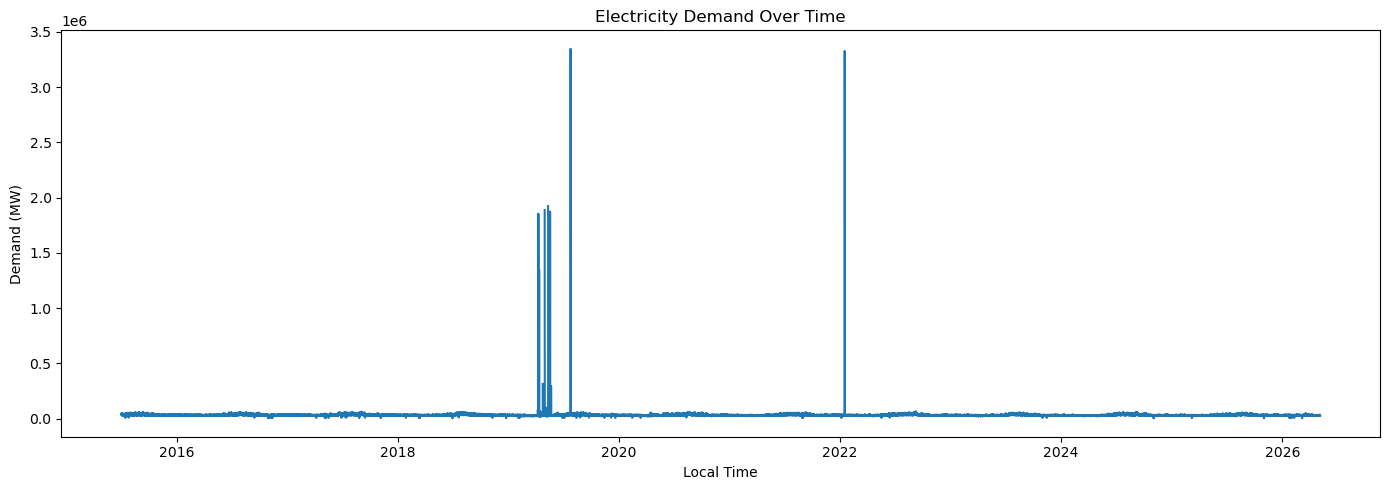

In [180]:
plt.figure(figsize=(14, 5))
plt.plot(df_eda["timestamp_local"], df_eda["region_demand_mw"])
plt.xlabel("Local Time")
plt.ylabel("Demand (MW)")
plt.title("Electricity Demand Over Time")
plt.tight_layout()
plt.show()

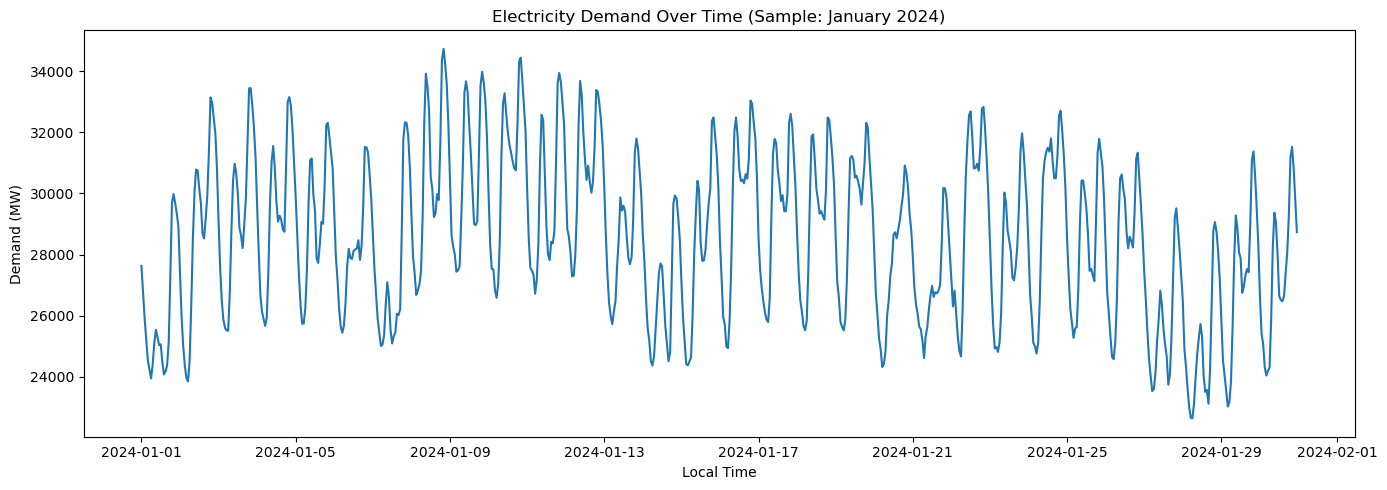

In [181]:
sample_start = "2024-01-01"
sample_end = "2024-01-31"

temp = df_eda[
    (df_eda["timestamp_local"] >= sample_start) &
    (df_eda["timestamp_local"] < sample_end)
].copy()

plt.figure(figsize=(14, 5))
plt.plot(temp["timestamp_local"], temp["region_demand_mw"])
plt.xlabel("Local Time")
plt.ylabel("Demand (MW)")
plt.title("Electricity Demand Over Time (Sample: January 2024)")
plt.tight_layout()
plt.show()

### average demand by local hour

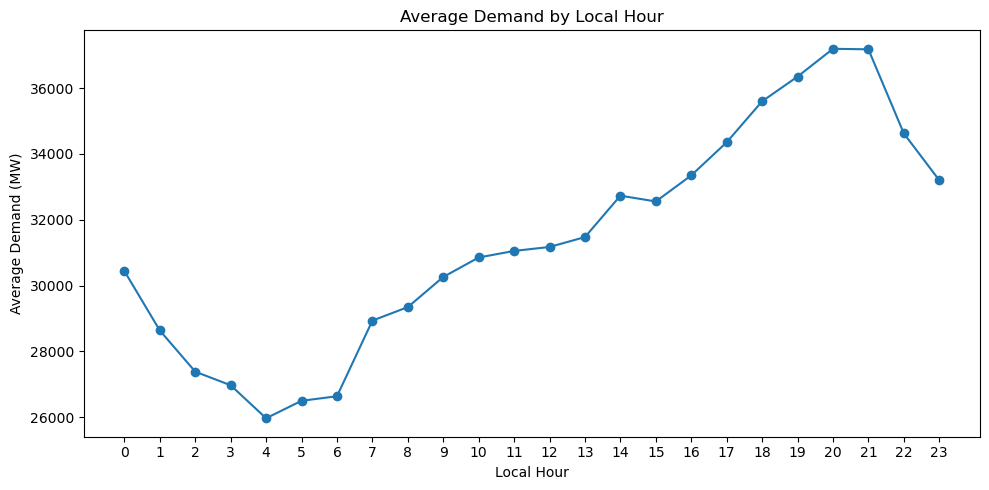

,local_hour,region_demand_mw
0,0,30439.823381
1,1,28633.198185
2,2,27380.944515
3,3,26967.521717
4,4,25965.238191
5,5,26495.961859
6,6,26633.944908
7,7,28933.983051
8,8,29344.495573
9,9,30260.176783


In [182]:
hourly_avg = (
    df_eda
    .groupby("local_hour", as_index=False)["region_demand_mw"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg["local_hour"], hourly_avg["region_demand_mw"], marker="o")
plt.xlabel("Local Hour")
plt.ylabel("Average Demand (MW)")
plt.title("Average Demand by Local Hour")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

hourly_avg

### average demand by day of week

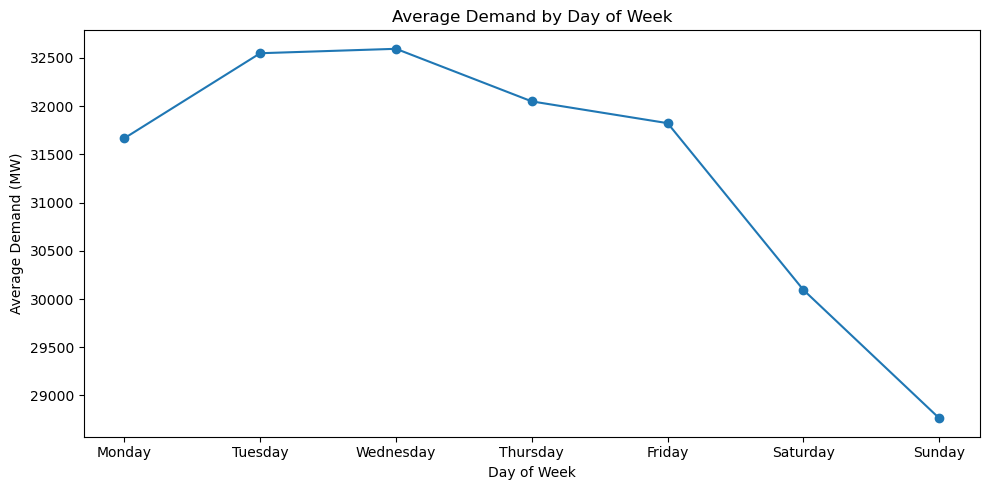

,local_day_name,region_demand_mw
1,Monday,31667.100450
5,Tuesday,32548.298583
6,Wednesday,32594.125692
4,Thursday,32048.903447
0,Friday,31823.142889
2,Saturday,30093.950937
3,Sunday,28763.750350


In [183]:
dow_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

dow_avg = (
    df_eda
    .groupby("local_day_name", as_index=False)["region_demand_mw"]
    .mean()
)

dow_avg["local_day_name"] = pd.Categorical(
    dow_avg["local_day_name"],
    categories=dow_order,
    ordered=True
)

dow_avg = dow_avg.sort_values("local_day_name")

plt.figure(figsize=(10, 5))
plt.plot(dow_avg["local_day_name"], dow_avg["region_demand_mw"], marker="o")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand (MW)")
plt.title("Average Demand by Day of Week")
plt.tight_layout()
plt.show()

dow_avg

### average demand by month of year

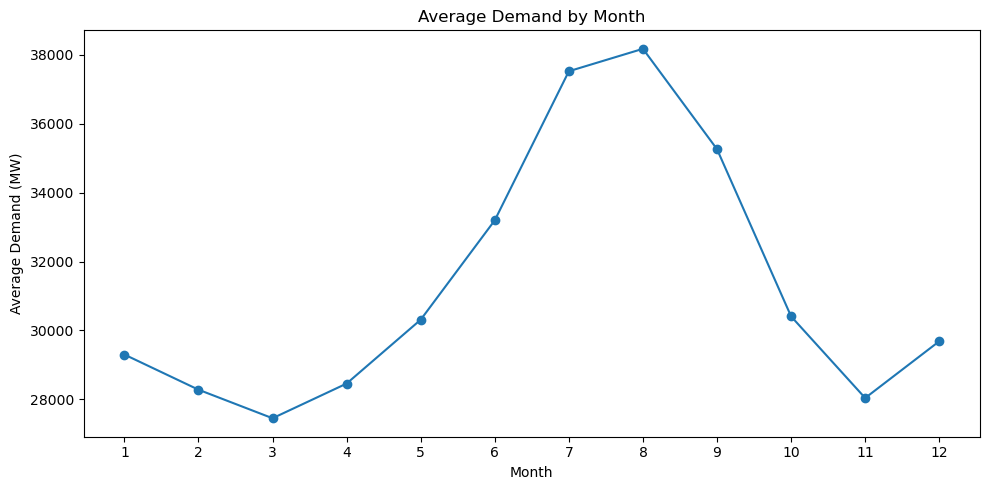

,local_month,region_demand_mw
0,1,29298.786779
1,2,28278.036174
2,3,27448.997553
3,4,28456.431468
4,5,30310.902116
5,6,33197.769722
6,7,37525.550532
7,8,38176.876711
8,9,35261.467172
9,10,30406.529570


In [184]:
month_avg = (
    df_eda
    .groupby("local_month", as_index=False)["region_demand_mw"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(month_avg["local_month"], month_avg["region_demand_mw"], marker="o")
plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")
plt.title("Average Demand by Month")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

month_avg

### average demand by day of year

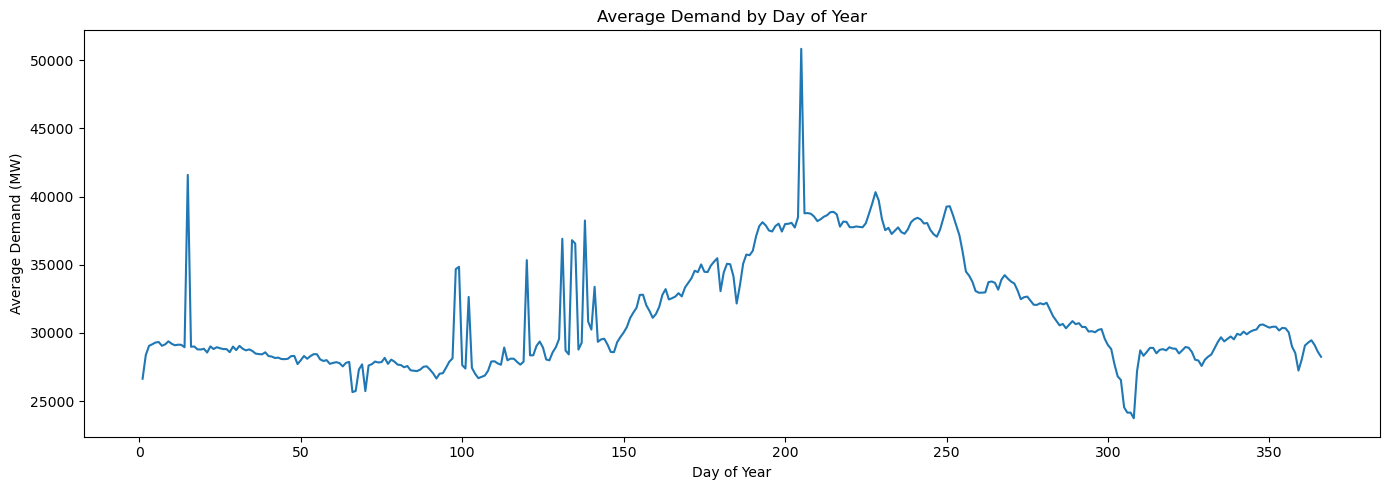

,day_of_year,region_demand_mw
0,1,26644.003788
1,2,28383.098485
2,3,29054.151515
3,4,29169.087121
4,5,29298.147727


In [185]:
doy_avg = (
    df_eda
    .groupby("day_of_year", as_index=False)["region_demand_mw"]
    .mean()
)

plt.figure(figsize=(14, 5))
plt.plot(doy_avg["day_of_year"], doy_avg["region_demand_mw"])
plt.xlabel("Day of Year")
plt.ylabel("Average Demand (MW)")
plt.title("Average Demand by Day of Year")
plt.tight_layout()
plt.show()

doy_avg.head()

### Holiday vs Non-Holiday Demand

In [186]:
holiday_avg = (
    df_eda
    .groupby("is_holiday")["region_demand_mw"]
    .agg(
        mean_demand_mw="mean",
        median_demand_mw="median",
        count="count"
    )
    .reset_index()
)

holiday_avg

,is_holiday,mean_demand_mw,median_demand_mw,count
0,No,31419.054077,30070.0,91795
1,Yes,29662.329753,28307.5,3072


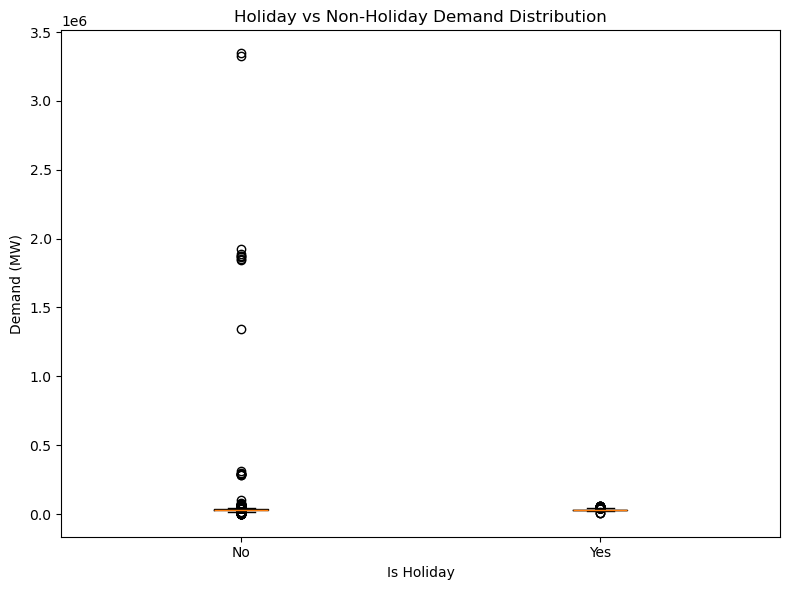

In [187]:
holiday_order = ["No", "Yes"]

box_data = [
    df_eda.loc[df_eda["is_holiday"] == label, "region_demand_mw"].dropna()
    for label in holiday_order
]

plt.figure(figsize=(8, 6))
plt.boxplot(box_data, tick_labels=holiday_order)
plt.xlabel("Is Holiday")
plt.ylabel("Demand (MW)")
plt.title("Holiday vs Non-Holiday Demand Distribution")
plt.tight_layout()
plt.show()

In [188]:
holiday_period_avg = (
    df_eda
    .groupby("is_holiday_period")["region_demand_mw"]
    .agg(
        mean_demand_mw="mean",
        median_demand_mw="median",
        count="count"
    )
    .reset_index()
)

holiday_period_avg

,is_holiday_period,mean_demand_mw,median_demand_mw,count
0,No,31489.955388,30128.0,86323
1,Yes,30071.082280,28900.0,8544


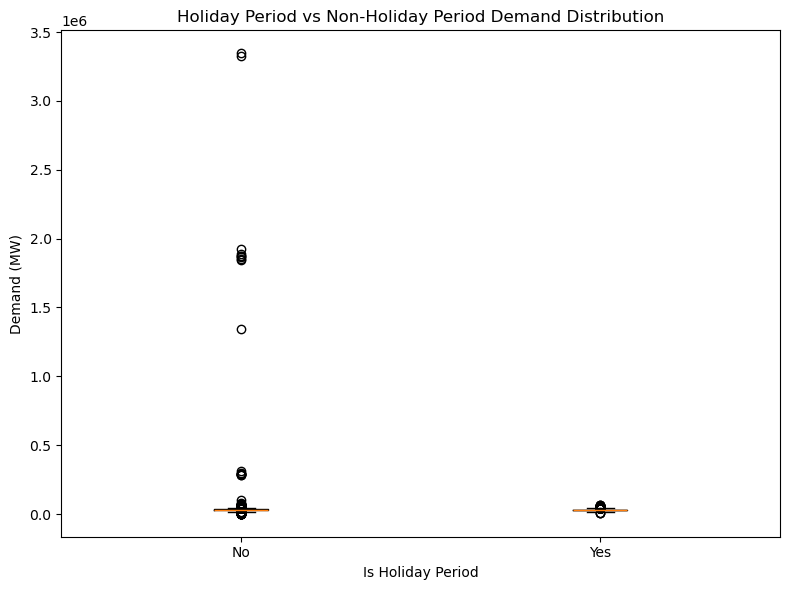

In [189]:
holiday_period_order = ["No", "Yes"]

box_data = [
    df_eda.loc[df_eda["is_holiday_period"] == label, "region_demand_mw"].dropna()
    for label in holiday_period_order
]

plt.figure(figsize=(8, 6))
plt.boxplot(box_data, tick_labels=holiday_period_order)
plt.xlabel("Is Holiday Period")
plt.ylabel("Demand (MW)")
plt.title("Holiday Period vs Non-Holiday Period Demand Distribution")
plt.tight_layout()
plt.show()

### Temperature vs demand

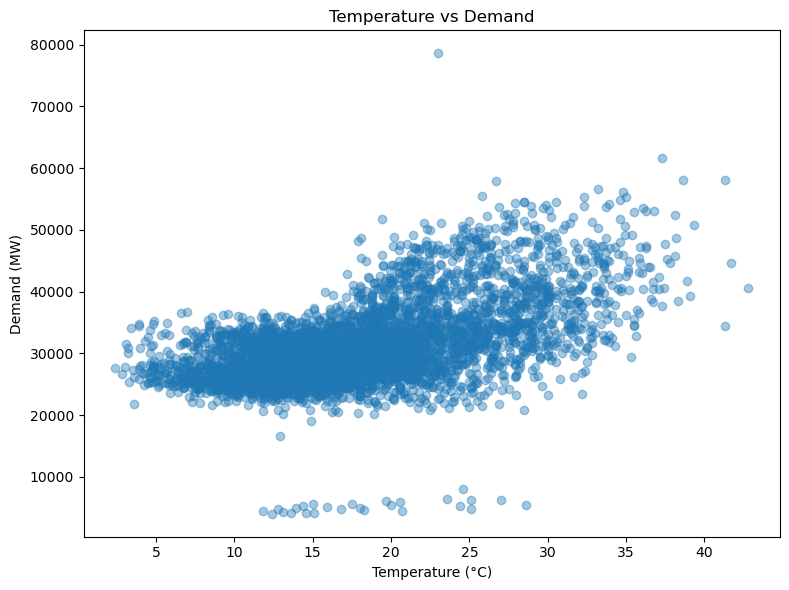

In [190]:
scatter_temp = df_eda[["temperature_2m", "region_demand_mw"]].dropna().sample(
    min(5000, len(df_eda.dropna(subset=["temperature_2m", "region_demand_mw"]))),
    random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(scatter_temp["temperature_2m"], scatter_temp["region_demand_mw"], alpha=0.4)
plt.xlabel("Temperature (°C)")
plt.ylabel("Demand (MW)")
plt.title("Temperature vs Demand")
plt.tight_layout()
plt.show()

C:\Users\surya\AppData\Local\Temp\ipykernel_30988\3281904900.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("temp_bin", as_index=False)["region_demand_mw"]


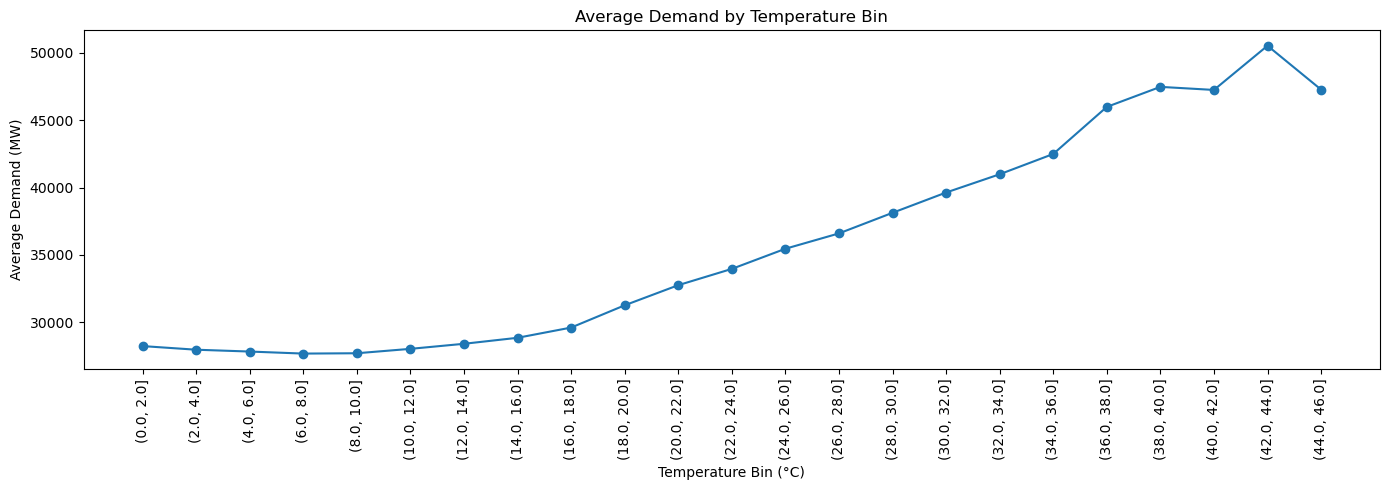

,temp_bin,region_demand_mw
0,"(0.0, 2.0]",28228.484375
1,"(2.0, 4.0]",27959.166667
2,"(4.0, 6.0]",27822.784615
3,"(6.0, 8.0]",27672.019082
4,"(8.0, 10.0]",27696.275577


In [191]:
df_temp_bin = df_eda[["temperature_2m", "region_demand_mw"]].dropna().copy()

df_temp_bin["temp_bin"] = pd.cut(
    df_temp_bin["temperature_2m"],
    bins=np.arange(
        np.floor(df_temp_bin["temperature_2m"].min()),
        np.ceil(df_temp_bin["temperature_2m"].max()) + 2,
        2
    )
)

temp_bin_avg = (
    df_temp_bin
    .groupby("temp_bin", as_index=False)["region_demand_mw"]
    .mean()
)

plt.figure(figsize=(14, 5))
plt.plot(temp_bin_avg["temp_bin"].astype(str), temp_bin_avg["region_demand_mw"], marker="o")
plt.xlabel("Temperature Bin (°C)")
plt.ylabel("Average Demand (MW)")
plt.title("Average Demand by Temperature Bin")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

temp_bin_avg.head()

### Cooling / Heating Degree vs Demand

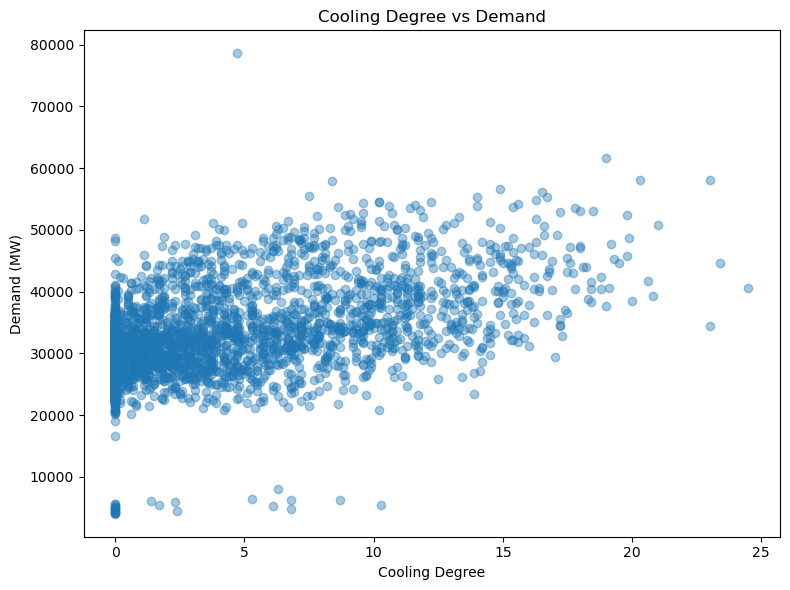

In [192]:
scatter_cd = df_eda[["cooling_degree", "region_demand_mw"]].dropna().sample(
    min(5000, len(df_eda.dropna(subset=["cooling_degree", "region_demand_mw"]))),
    random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(scatter_cd["cooling_degree"], scatter_cd["region_demand_mw"], alpha=0.4)
plt.xlabel("Cooling Degree")
plt.ylabel("Demand (MW)")
plt.title("Cooling Degree vs Demand")
plt.tight_layout()
plt.show()

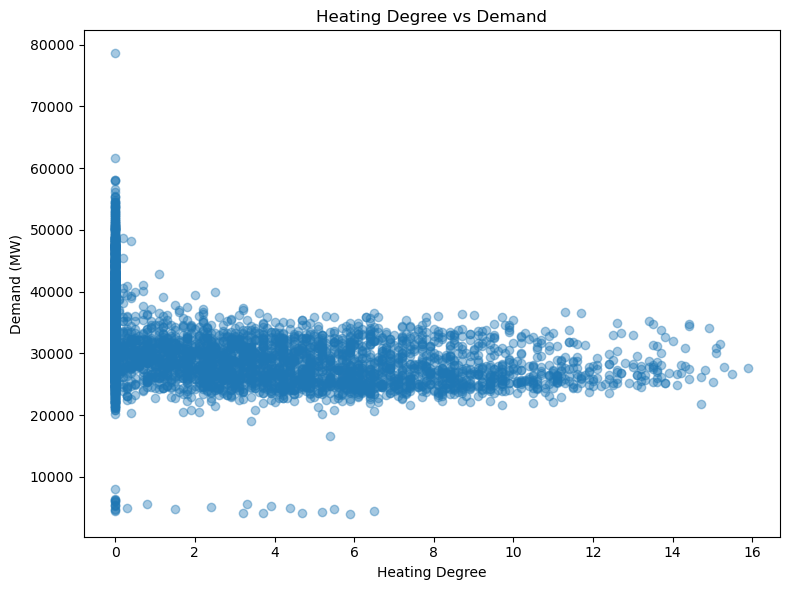

In [193]:
scatter_hd = df_eda[["heating_degree", "region_demand_mw"]].dropna().sample(
    min(5000, len(df_eda.dropna(subset=["heating_degree", "region_demand_mw"]))),
    random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(scatter_hd["heating_degree"], scatter_hd["region_demand_mw"], alpha=0.4)
plt.xlabel("Heating Degree")
plt.ylabel("Demand (MW)")
plt.title("Heating Degree vs Demand")
plt.tight_layout()
plt.show()

In [194]:
corr_cols = [
    "region_demand_mw",
    "temperature_2m",
    "cooling_degree",
    "heating_degree"
]

df_eda[corr_cols].corr()

,region_demand_mw,temperature_2m,cooling_degree,heating_degree
region_demand_mw,1.000000,0.153403,0.154264,-0.105442
temperature_2m,0.153403,1.000000,0.884274,-0.831623
cooling_degree,0.154264,0.884274,1.000000,-0.476055
heating_degree,-0.105442,-0.831623,-0.476055,1.000000


### Actual Demand vs EIA Demand Forecast

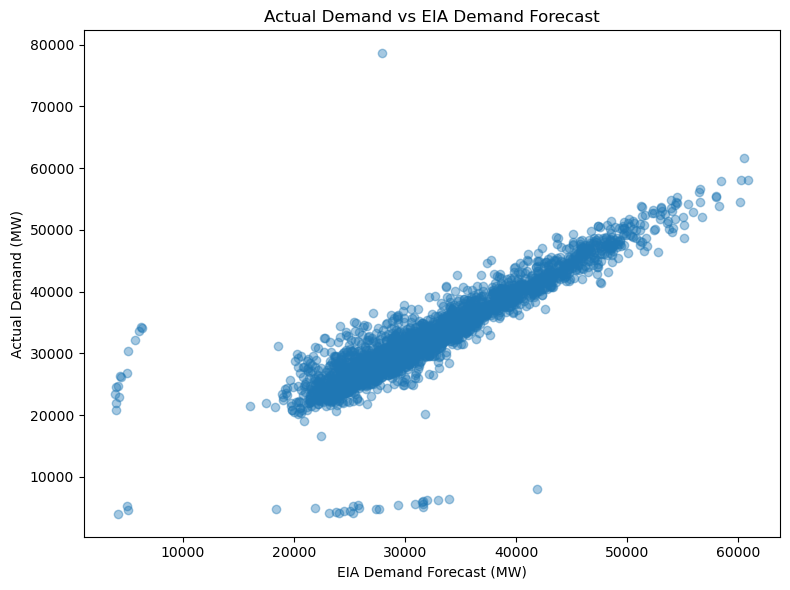

In [195]:
scatter_forecast = df_eda[["region_demand_forecast_mw", "region_demand_mw"]].dropna().sample(
    min(5000, len(df_eda.dropna(subset=["region_demand_forecast_mw", "region_demand_mw"]))),
    random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(
    scatter_forecast["region_demand_forecast_mw"],
    scatter_forecast["region_demand_mw"],
    alpha=0.4
)
plt.xlabel("EIA Demand Forecast (MW)")
plt.ylabel("Actual Demand (MW)")
plt.title("Actual Demand vs EIA Demand Forecast")
plt.tight_layout()
plt.show()

In [196]:
df_eda["forecast_error_mw"] = df_eda["region_demand_forecast_mw"] - df_eda["region_demand_mw"]
df_eda["abs_forecast_error_mw"] = df_eda["forecast_error_mw"].abs()

forecast_error_summary = df_eda["forecast_error_mw"].describe()
forecast_error_summary

count    9.486700e+04
mean    -7.138341e+02
std      2.260021e+04
min     -3.295240e+06
25%     -1.113000e+03
50%     -3.710000e+02
75%      3.340000e+02
max      4.052000e+04
Name: forecast_error_mw, dtype: float64

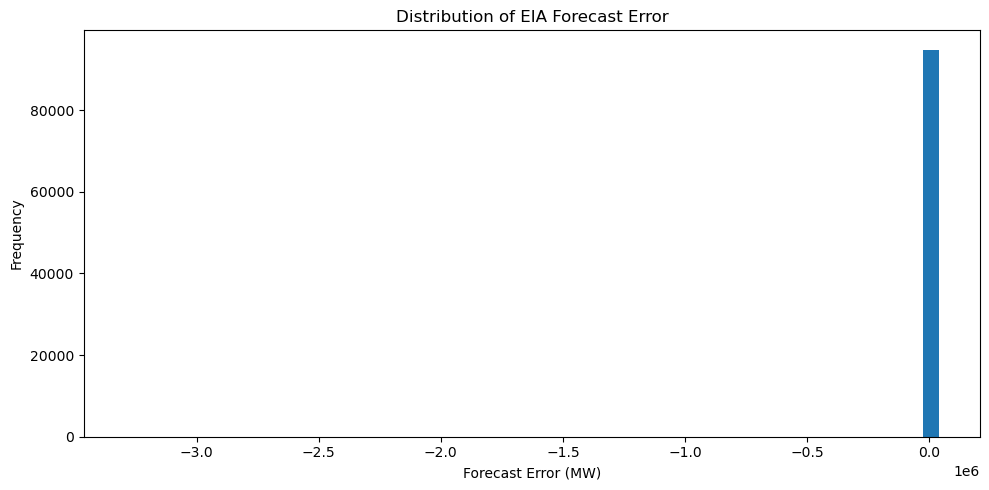

In [197]:
plt.figure(figsize=(10, 5))
plt.hist(df_eda["forecast_error_mw"].dropna(), bins=50)
plt.xlabel("Forecast Error (MW)")
plt.ylabel("Frequency")
plt.title("Distribution of EIA Forecast Error")
plt.tight_layout()
plt.show()

### Lag Relationship: Demand vs Lag 24h

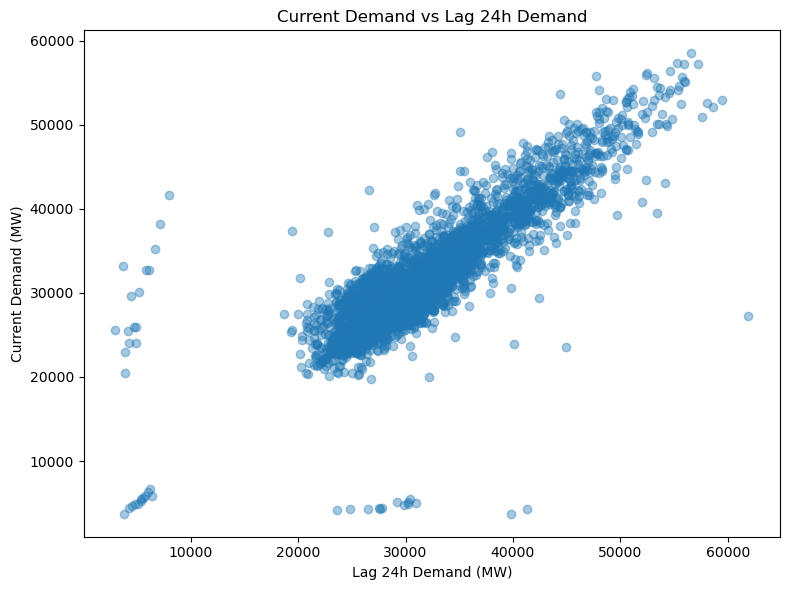

,region_demand_mw,lag_24h
region_demand_mw,1.000000,0.076073
lag_24h,0.076073,1.000000


In [198]:
lag24_df = df_eda[["lag_24h", "region_demand_mw"]].dropna().sample(
    min(5000, len(df_eda.dropna(subset=["lag_24h", "region_demand_mw"]))),
    random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(lag24_df["lag_24h"], lag24_df["region_demand_mw"], alpha=0.4)
plt.xlabel("Lag 24h Demand (MW)")
plt.ylabel("Current Demand (MW)")
plt.title("Current Demand vs Lag 24h Demand")
plt.tight_layout()
plt.show()

df_eda[["region_demand_mw", "lag_24h"]].corr()

### correlation matrix

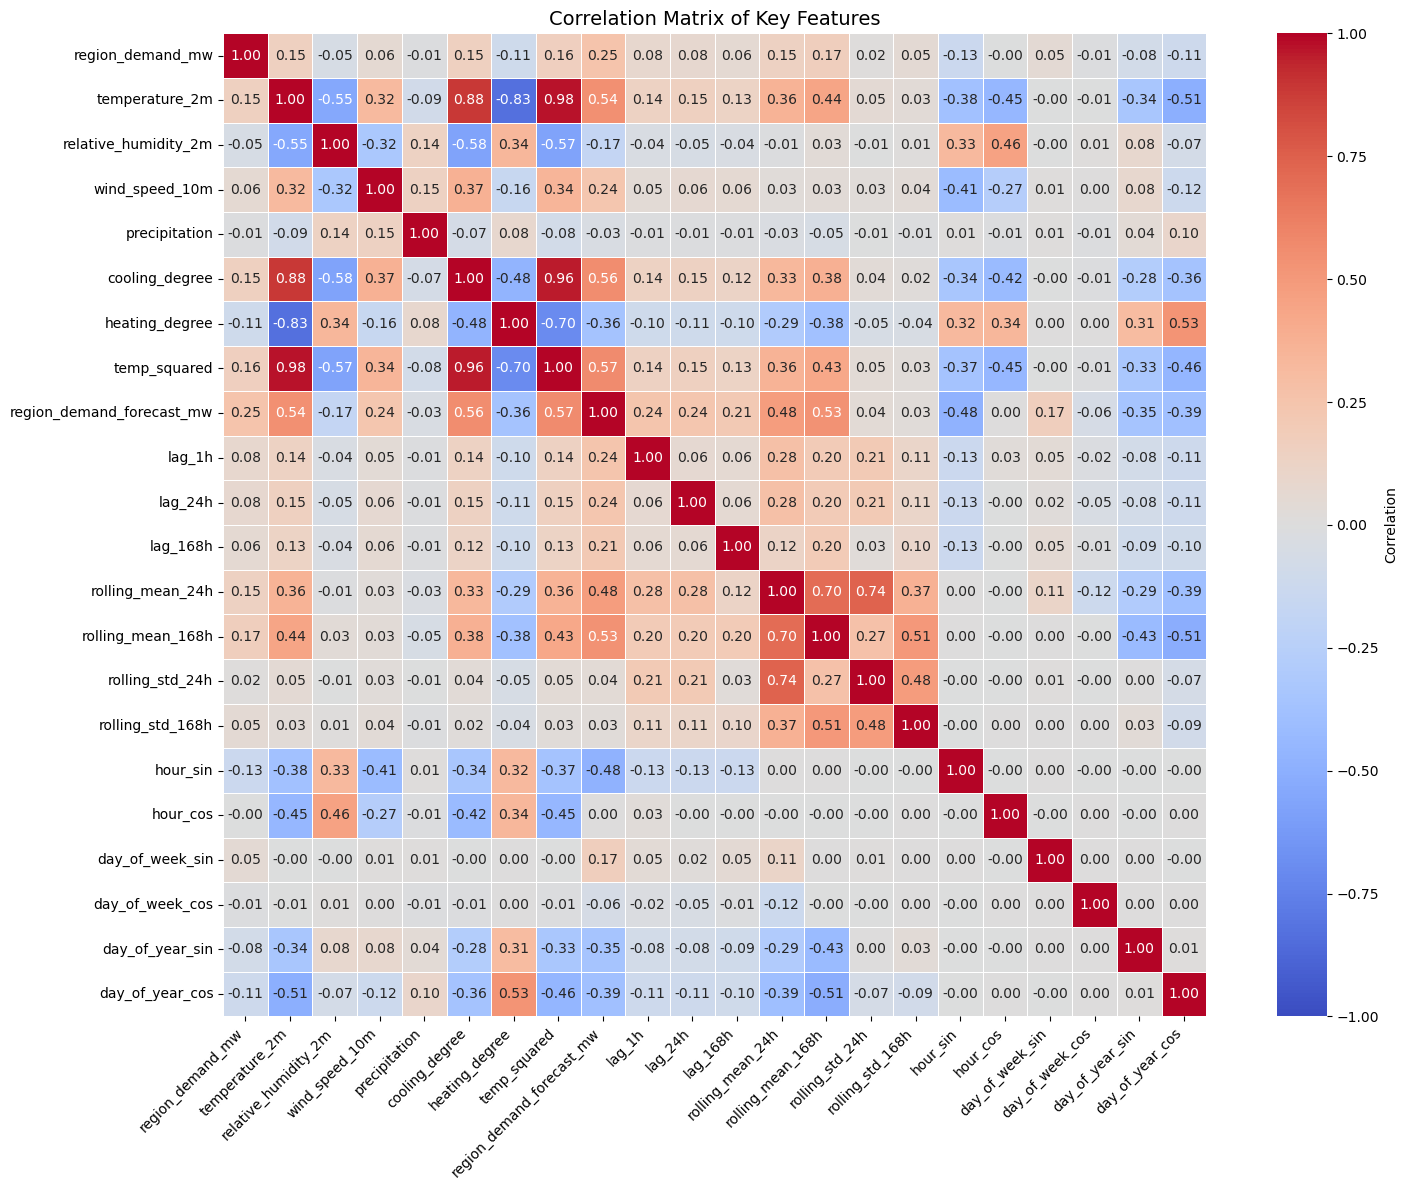

In [199]:
corr_cols = [
    "region_demand_mw",
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "precipitation",
    "cooling_degree",
    "heating_degree",
    "temp_squared",
    "region_demand_forecast_mw",
    "lag_1h",
    "lag_24h",
    "lag_168h",
    "rolling_mean_24h",
    "rolling_mean_168h",
    "rolling_std_24h",
    "rolling_std_168h",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos"
]

# Keep only columns that exist
corr_cols = [col for col in corr_cols if col in df_eda.columns]

corr_matrix = df_eda[corr_cols].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Matrix of Key Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

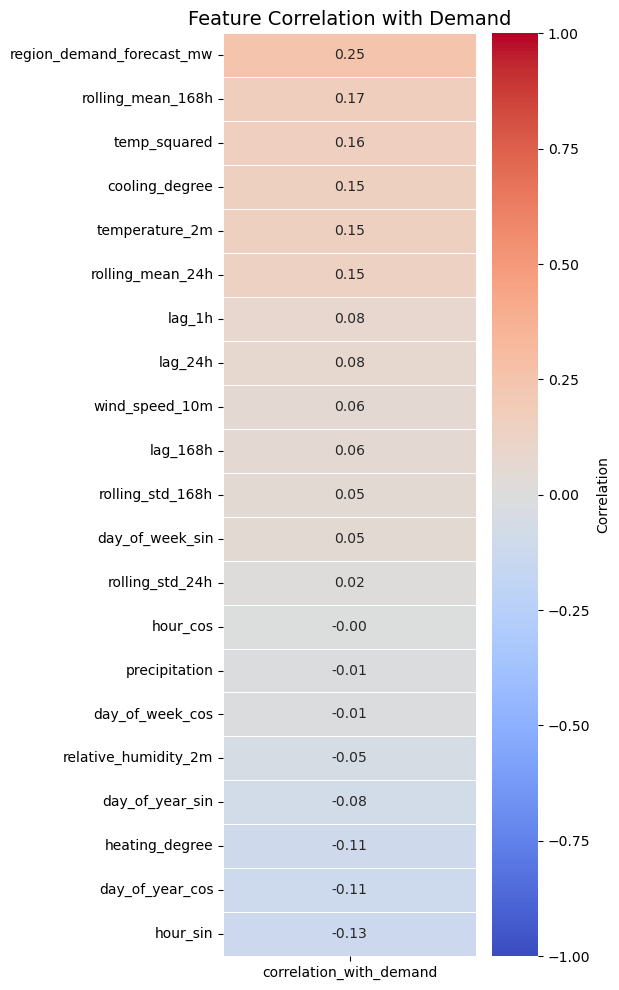

,correlation_with_demand
region_demand_forecast_mw,0.252930
rolling_mean_168h,0.170983
temp_squared,0.158359
cooling_degree,0.154264
temperature_2m,0.153403
rolling_mean_24h,0.146108
lag_1h,0.081103
lag_24h,0.076073
wind_speed_10m,0.061332
lag_168h,0.057507


In [200]:
target_corr = (
    corr_matrix["region_demand_mw"]
    .drop("region_demand_mw")
    .sort_values(ascending=False)
    .to_frame(name="correlation_with_demand")
)

plt.figure(figsize=(6, 10))

sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Feature Correlation with Demand", fontsize=14)
plt.tight_layout()
plt.show()

target_corr

# Data Splitting

---

* Warm-up / history : 2015-07-01 sampai 2017-06-30
* Train             : 2017-07-01 sampai 2023-12-31
* Validation        : 2024-01-01 sampai 2024-12-31
* Test              : 2025-01-01 sampai 2026-05-06

In [201]:
SPLIT_OUTPUT_DIR = "final_splits"

df_split = df.copy()

df_split["timestamp_utc"] = pd.to_datetime(df_split["timestamp_utc"], utc=True)
df_split["data_date"] = pd.to_datetime(df_split["data_date"], errors="coerce")

missing_data_date = df_split["data_date"].isna().sum()
missing_timestamp = df_split["timestamp_utc"].isna().sum()

print("Missing data_date after conversion:", missing_data_date)
print("Missing timestamp_utc after conversion:", missing_timestamp)

warmup_start_date = pd.Timestamp("2015-07-01")
modeling_start_date = pd.Timestamp("2017-07-01")

train_end_date = pd.Timestamp("2024-01-01")
valid_end_date = pd.Timestamp("2025-01-01")
test_end_date = pd.Timestamp("2026-05-07")  # exclusive

df_split = df_split.sort_values("timestamp_utc").reset_index(drop=True)

warmup_df = df_split[
    (df_split["data_date"] >= warmup_start_date) &
    (df_split["data_date"] < modeling_start_date)
].copy()

train_df = df_split[
    (df_split["data_date"] >= modeling_start_date) &
    (df_split["data_date"] < train_end_date)
].copy()

valid_df = df_split[
    (df_split["data_date"] >= train_end_date) &
    (df_split["data_date"] < valid_end_date)
].copy()

test_df = df_split[
    (df_split["data_date"] >= valid_end_date) &
    (df_split["data_date"] < test_end_date)
].copy()

# Do not drop NA here.
# Keep full timeline for lag/rolling/window feature engineering.
warmup_df = warmup_df.reset_index(drop=True)
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

warmup_df.to_csv(f"{SPLIT_OUTPUT_DIR}/warmup_2015H2_2017H1.csv", index=False)
train_df.to_csv(f"{SPLIT_OUTPUT_DIR}/train_2017H2_2023H2.csv", index=False)
valid_df.to_csv(f"{SPLIT_OUTPUT_DIR}/valid_2024.csv", index=False)
test_df.to_csv(f"{SPLIT_OUTPUT_DIR}/test_2025_2026May.csv", index=False)

print("Saved split datasets to:", SPLIT_OUTPUT_DIR)
print()
print("Warm-up:", warmup_df.shape, warmup_df["timestamp_utc"].min(), "to", warmup_df["timestamp_utc"].max())
print("Train:", train_df.shape, train_df["timestamp_utc"].min(), "to", train_df["timestamp_utc"].max())
print("Validation:", valid_df.shape, valid_df["timestamp_utc"].min(), "to", valid_df["timestamp_utc"].max())
print("Test:", test_df.shape, test_df["timestamp_utc"].min(), "to", test_df["timestamp_utc"].max())

print()
print("Missing target check:")
print("Warm-up target_region_demand_mw missing:", warmup_df["target_region_demand_mw"].isna().sum())
print("Train target_region_demand_mw missing:", train_df["target_region_demand_mw"].isna().sum())
print("Validation actual region_demand_mw missing:", valid_df["region_demand_mw"].isna().sum())
print("Test actual region_demand_mw missing:", test_df["region_demand_mw"].isna().sum())

Missing data_date after conversion: 0
Missing timestamp_utc after conversion: 0
Saved split datasets to: final_splits

Warm-up: (17544, 49) 2015-07-01 08:00:00+00:00 to 2017-07-01 07:00:00+00:00
Train: (57001, 49) 2017-07-01 08:00:00+00:00 to 2024-01-01 08:00:00+00:00
Validation: (8784, 49) 2024-01-01 09:00:00+00:00 to 2025-01-01 08:00:00+00:00
Test: (11759, 49) 2025-01-01 09:00:00+00:00 to 2026-05-06 07:00:00+00:00

Missing target check:
Warm-up target_region_demand_mw missing: 0
Train target_region_demand_mw missing: 0
Validation actual region_demand_mw missing: 0
Test actual region_demand_mw missing: 0
